# Preprocessing, Feature Engineering and Modeling
### Customer Churn Prediction

Train models on the churn data and review the main results.

Models: Logistic Regression baseline, XGBoost primary, plus SHAP explainability
Primary metrics: ROC-AUC, F1, precision, recall

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)

# XGBoost
from xgboost import XGBClassifier

# SHAP
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

print('All imports successful.')

All imports successful.


## Load data and clean

Read the dataset, fix the known issue in `TotalCharges`, remove `customerID`, and convert the target.

In [4]:
df = pd.read_csv('../data/telco_churn.csv')

# Fix TotalCharges (whitespace strings to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop customerID
df.drop(columns=['customerID'], inplace=True)

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f'Shape: {df.shape}')
print(f'Churn distribution:\n{df["Churn"].value_counts()}')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Shape: (7043, 20)
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Missing values:
TotalCharges    11
dtype: int64


## Feature engineering

Add a few useful fields from the data before splitting into train and test sets.

In [ ]:
# Feature engineering

# Tenure group (binned)
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4+yr']
).astype(str)

# 2. Avg monthly spend proxy (TotalCharges / tenure)
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)  # +1 to avoid div by zero

# 3. Has any streaming service
df['has_streaming'] = (
    (df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')
).astype(int)

# 4. Number of add-on services
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_addons'] = df[addon_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

# Month-to-month contract flag
df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

# Electronic check payment flag
df['is_elec_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

print('Feature engineering complete.')
print(f'New shape: {df.shape}')
df[['tenure_group', 'avg_monthly_spend', 'has_streaming', 'num_addons',
    'is_month_to_month', 'is_elec_check']].head()

Feature engineering complete.
New shape: (7043, 26)


,tenure_group,avg_monthly_spend,has_streaming,num_addons,is_month_to_month,is_elec_check
0,0-1yr,14.925000,0,1,1,1
1,2-4yr,53.985714,0,2,0,0
2,0-1yr,36.050000,0,2,1,0
3,2-4yr,40.016304,0,3,0,0
4,0-1yr,50.550000,0,0,1,1


## Define features and split

Set the target and split the data with stratification so churn ratio stays the same.

In [6]:
TARGET = 'Churn'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features  ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

# Stratified split preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}')

Numeric features  (9): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'has_streaming', 'num_addons', 'is_month_to_month', 'is_elec_check']
Categorical features (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

Train size: 5634 | Test size: 1409
Train churn rate: 0.265 | Test churn rate: 0.265


## Preprocessing pipeline

Build the numeric and categorical preprocessing steps and combine them into one transformer.

In [7]:
# Numeric pipeline: impute median then scale
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute mode then one-hot encode
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print('Preprocessing pipeline defined.')

Preprocessing pipeline defined.


## Baseline model

Train a logistic regression baseline so we have a reference for the more complex model.

In [8]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_probs = lr_pipeline.predict_proba(X_test)[:, 1]

print('Logistic regression baseline results:')
print(f'ROC-AUC : {roc_auc_score(y_test, lr_probs):.4f}')
print(f'F1 Score: {f1_score(y_test, lr_preds):.4f}')
print(f'Precision: {precision_score(y_test, lr_preds):.4f}')
print(f'Recall  : {recall_score(y_test, lr_preds):.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['No Churn', 'Churn']))

Logistic regression baseline results:
ROC-AUC : 0.8460
F1 Score: 0.6126
Precision: 0.5052
Recall  : 0.7781

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Primary model

Train XGBoost and use `scale_pos_weight` to account for class imbalance.

In [9]:
# Calculate scale_pos_weight for class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f} (neg/pos ratio)')

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)
xgb_probs = xgb_pipeline.predict_proba(X_test)[:, 1]

print('\nXGBoost results:')
print(f'ROC-AUC : {roc_auc_score(y_test, xgb_probs):.4f}')
print(f'F1 Score: {f1_score(y_test, xgb_preds):.4f}')
print(f'Precision: {precision_score(y_test, xgb_preds):.4f}')
print(f'Recall  : {recall_score(y_test, xgb_preds):.4f}')
print()
print(classification_report(y_test, xgb_preds, target_names=['No Churn', 'Churn']))

scale_pos_weight: 2.77 (neg/pos ratio)

XGBoost results:
ROC-AUC : 0.8406
F1 Score: 0.6262
Precision: 0.5264
Recall  : 0.7727

              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



## Cross-validation

Run 5-fold cross-validation to check that the XGBoost model performs consistently.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_f1  = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

print('5-fold cross-validation results:')
print(f'ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'F1 Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

5-fold cross-validation results:
ROC-AUC : 0.8442 ± 0.0094
F1 Score: 0.6347 ± 0.0139


## Evaluation plots

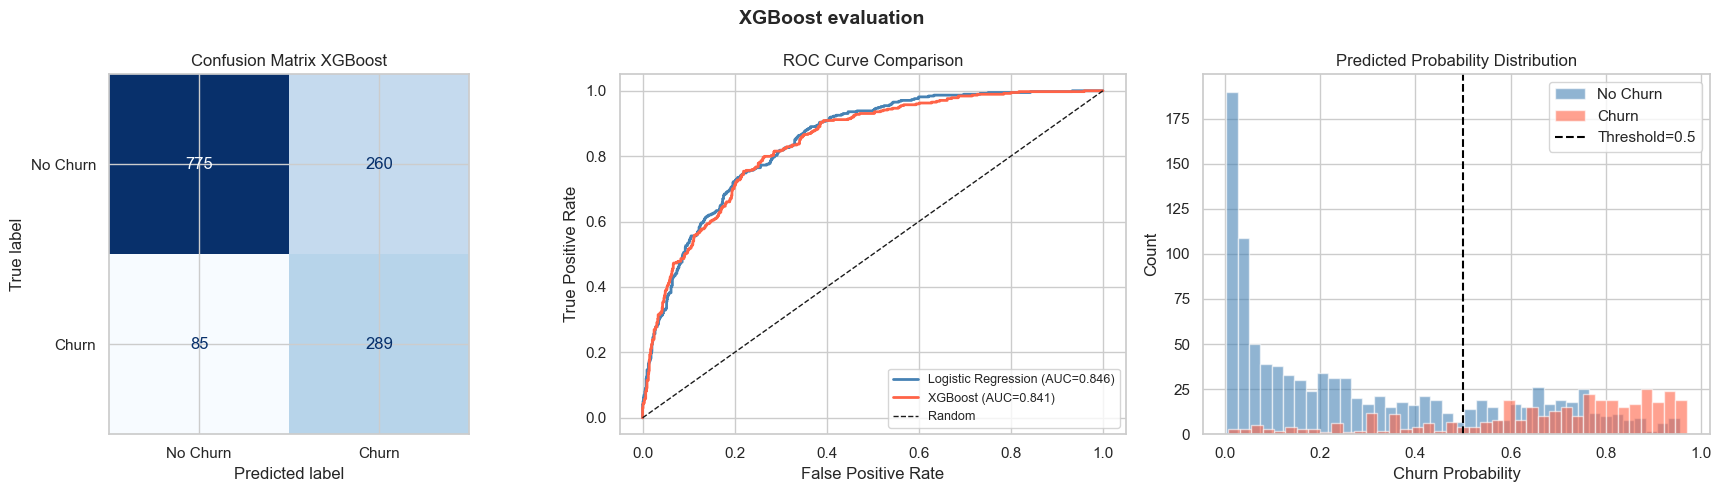

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, xgb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix XGBoost', fontsize=12)

# ROC curve for both models
for probs, label, color in [
    (lr_probs, f'Logistic Regression (AUC={roc_auc_score(y_test, lr_probs):.3f})', 'steelblue'),
    (xgb_probs, f'XGBoost (AUC={roc_auc_score(y_test, xgb_probs):.3f})', 'tomato')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[1].plot(fpr, tpr, label=label, color=color, lw=2)
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_title('ROC Curve Comparison', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

# Prediction probability distribution
axes[2].hist(xgb_probs[y_test == 0], bins=40, alpha=0.6, label='No Churn', color='steelblue', edgecolor='white')
axes[2].hist(xgb_probs[y_test == 1], bins=40, alpha=0.6, label='Churn', color='tomato', edgecolor='white')
axes[2].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[2].set_title('Predicted Probability Distribution', fontsize=12)
axes[2].set_xlabel('Churn Probability')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('XGBoost evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

There are 260 false negatives, so the model has predicted churn for 260 individuals whereas the true label was no churn. 

## Threshold tuning

Default threshold is 0.5. For churn we may prefer higher recall.
Find the threshold that gives the best F1 score.

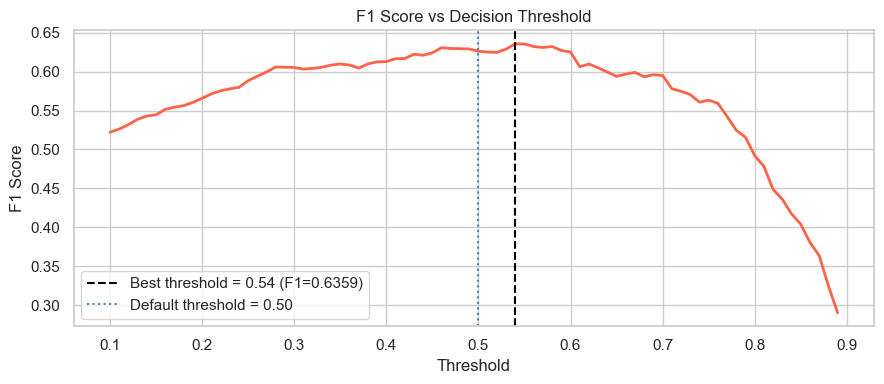

Best threshold: 0.54
Best F1 Score : 0.6359
Tuned threshold results:
              precision    recall  f1-score   support

    No Churn       0.90      0.78      0.83      1035
       Churn       0.55      0.75      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



In [12]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (xgb_probs >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, color='tomato', lw=2)
plt.axvline(best_threshold, color='black', linestyle='--', lw=1.5,
            label=f'Best threshold = {best_threshold:.2f} (F1={best_f1:.4f})')
plt.axvline(0.5, color='steelblue', linestyle=':', lw=1.5, label='Default threshold = 0.50')
plt.title('F1 Score vs Decision Threshold', fontsize=12)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best threshold: {best_threshold:.2f}')
print(f'Best F1 Score : {best_f1:.4f}')

# Apply best threshold
xgb_preds_tuned = (xgb_probs >= best_threshold).astype(int)
print('Tuned threshold results:')
print(classification_report(y_test, xgb_preds_tuned, target_names=['No Churn', 'Churn']))

## SHAP explainability

SHapley Additive exPlanation is a method for explaining why a machine learning model made a particular prediction by assigning each feature a contribution value based on shapley values from game theory. 

In [13]:
# Get preprocessed feature names
preprocessor_fitted = xgb_pipeline.named_steps['preprocessor']
cat_encoder = preprocessor_fitted.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names

# Transform test set
X_test_transformed = preprocessor_fitted.transform(X_test)

# SHAP explainer
explainer = shap.TreeExplainer(xgb_pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Feature names: {len(all_feature_names)}')

SHAP values shape: (1409, 54)
Feature names: 54


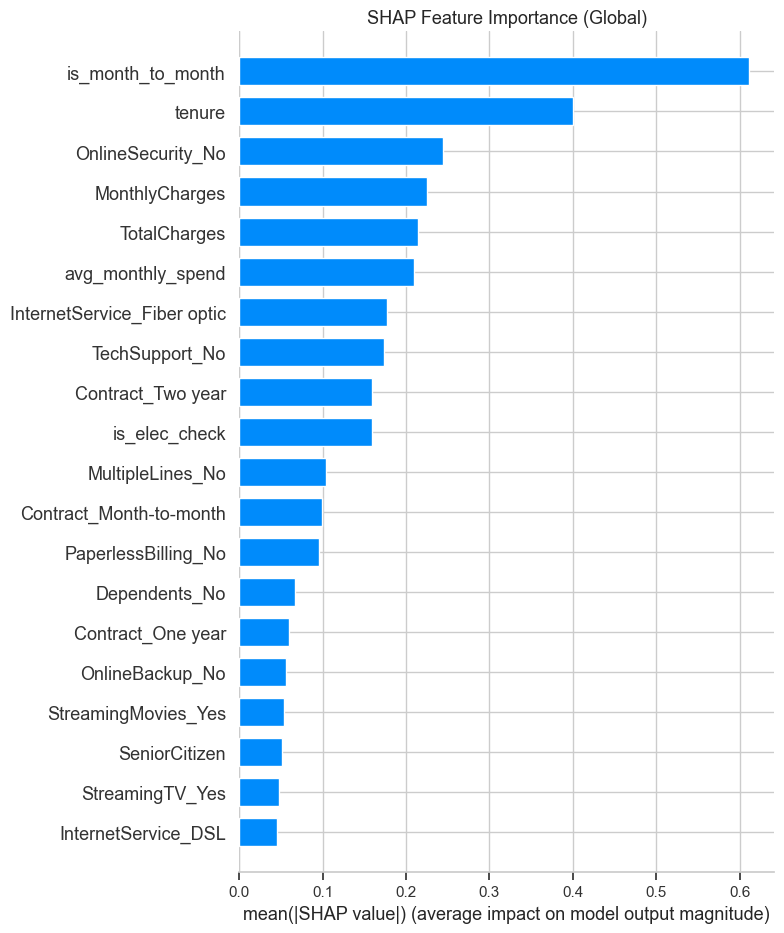

In [14]:
# SHAP summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=all_feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (Global)', fontsize=13)
plt.tight_layout()
plt.show()

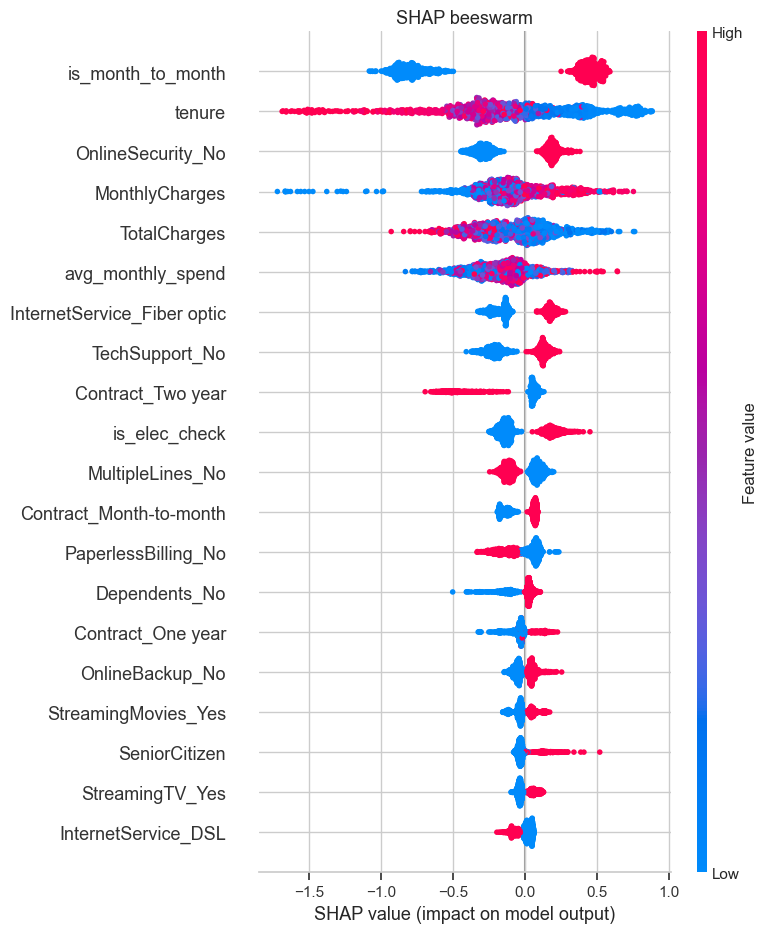

In [15]:
# SHAP beeswarm plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=all_feature_names,
    show=False
)
plt.title('SHAP beeswarm', fontsize=13)
plt.tight_layout()
plt.show()

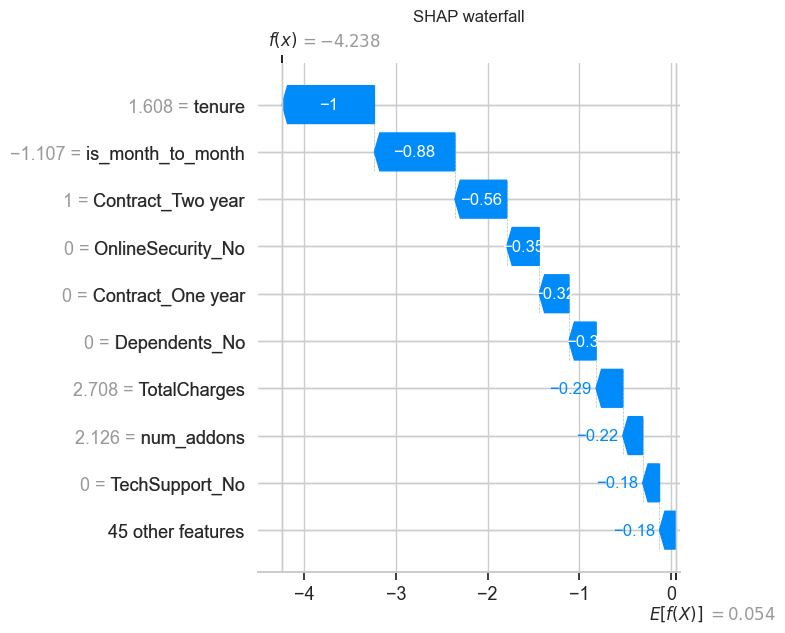

In [16]:
# SHAP waterfall for one prediction
shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test_transformed[0],
    feature_names=all_feature_names
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_explanation, show=False)
plt.title('SHAP waterfall', fontsize=12)
plt.tight_layout()
plt.show()

## Model comparison

In [17]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'XGBoost (tuned threshold)'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr_probs), 4),
        round(roc_auc_score(y_test, xgb_probs), 4),
        round(roc_auc_score(y_test, xgb_probs), 4)
    ],
    'F1 Score': [
        round(f1_score(y_test, lr_preds), 4),
        round(f1_score(y_test, xgb_preds), 4),
        round(f1_score(y_test, xgb_preds_tuned), 4)
    ],
    'Precision': [
        round(precision_score(y_test, lr_preds), 4),
        round(precision_score(y_test, xgb_preds), 4),
        round(precision_score(y_test, xgb_preds_tuned), 4)
    ],
    'Recall': [
        round(recall_score(y_test, lr_preds), 4),
        round(recall_score(y_test, xgb_preds), 4),
        round(recall_score(y_test, xgb_preds_tuned), 4)
    ]
})

print('Model comparison:')
print(results.to_string(index=False))

Model comparison:
                    Model  ROC-AUC  F1 Score  Precision  Recall
      Logistic Regression   0.8460    0.6126     0.5052  0.7781
                  XGBoost   0.8406    0.6262     0.5264  0.7727
XGBoost (tuned threshold)   0.8406    0.6359     0.5497  0.7540


XGBoost only gives a small improvement over logistic regression here: it is a bit stronger on F1 and precision, while logistic has a tiny edge on ROC-AUC and recall. 
The tuned XGBoost threshold is the best balance for capturing churn without losing too much recall.

## Save model and artifacts

In [18]:
# Save the full pipeline (preprocessor + model)
joblib.dump(xgb_pipeline, '../models/churn_model.joblib')

# Save best threshold
joblib.dump(best_threshold, '../models/best_threshold.joblib')

# Save feature names (needed for API input validation)
joblib.dump(list(X.columns), '../models/feature_names.joblib')

print('Saved:')
print('  ../models/churn_model.joblib')
print('  ../models/best_threshold.joblib')
print('  ../models/feature_names.joblib')
print()
print('These artifacts will be loaded by the FastAPI app for inference.')

Saved:
  ../models/churn_model.joblib
  ../models/best_threshold.joblib
  ../models/feature_names.joblib

These artifacts will be loaded by the FastAPI app for inference.


## Modeling complete

What we built:
- preprocessing pipeline with numeric and categorical steps
- feature engineering with new churn-related features
- baseline model with logistic regression
- primary model with XGBoost and class imbalance handling
- 5-fold cross-validation
- threshold tuning for F1
- SHAP explainability for global and local insights
- saved model files for inference

Next: `api/main.py` loads the model and serves predictions.